In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ivishalkr","key":"76ae1de881b2718dadd2886d2357ad24"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import kagglehub

path = kagglehub.dataset_download("biaiscience/dogs-vs-cats")

print("Path to dataset files:", path)

100%|██████████| 817M/817M [00:38<00:00, 22.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/biaiscience/dogs-vs-cats/versions/1


In [5]:
import os
print(os.listdir(path))

['train', 'test']


In [6]:
train_path = path + "/train"
test_path = path + "/test"

print(os.listdir(train_path))
print(os.listdir(test_path))

['train']
['test']


In [7]:
!unzip -q "ZIP_PATH" -d "OUTPUT_FOLDER"

unzip:  cannot find or open ZIP_PATH, ZIP_PATH.zip or ZIP_PATH.ZIP.


In [8]:
print(path)
print(os.listdir(path))

/root/.cache/kagglehub/datasets/biaiscience/dogs-vs-cats/versions/1
['train', 'test']


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,BatchNormalization,Dropout
from tensorflow.keras.models import Sequential

In [10]:
import os
import shutil

src = path + "/train/train"
base_dir = "/content/cats_vs_dogs"

cat_dir = base_dir + "/cats"
dog_dir = base_dir + "/dogs"

os.makedirs(cat_dir, exist_ok=True)
os.makedirs(dog_dir, exist_ok=True)

for file in os.listdir(src):
    if file.startswith("cat"):
        shutil.copy(os.path.join(src, file), cat_dir)
    elif file.startswith("dog"):
        shutil.copy(os.path.join(src, file), dog_dir)

print("Dataset organized!")

Dataset organized!


In [11]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory="/content/cats_vs_dogs",
    labels="inferred",
    label_mode="int",
    image_size=(224,224),
    batch_size=32
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory="/content/cats_vs_dogs",
    labels="inferred",
    label_mode="int",
    # validation_split=0.2,
    # subset="validation",
    # seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 25000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


In [12]:
# Normalize
def process(image, label):
    image = tf.cast(image/255.0, tf.float32)
    return image,label
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)


In [13]:
# Create CNN Model
model = Sequential()

# FIX: match dataset size (224,224,3)
model.add(Conv2D(32, kernel_size=(3,3), padding="valid",activation="relu", input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding="valid"))

model.add(Conv2D(64, kernel_size=(3,3), padding="valid", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding="valid"))

model.add(Conv2D(128, kernel_size=(3,3), padding="valid", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding="valid"))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.1))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.1))
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,177 (42.64 MB)

 Trainable params: 11,177,729 (42.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [16]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 112ms/step - accuracy: 0.5584 - loss: 1.9215 - val_accuracy: 0.5622 - val_loss: 0.6359
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 124ms/step - accuracy: 0.6288 - loss: 0.6230 - val_accuracy: 0.6823 - val_loss: 0.5887
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 120ms/step - accuracy: 0.7361 - loss: 0.5121 - val_accuracy: 0.7784 - val_loss: 0.4602
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 101ms/step - accuracy: 0.7902 - loss: 0.4372 - val_accuracy: 0.8166 - val_loss: 0.3930
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 102ms/step - accuracy: 0.8141 - loss: 0.3877 - val_accuracy: 0.8252 - val_loss: 0.3805
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 101ms/step - accuracy: 0.8456 - loss: 0.3408 - val_accuracy: 0.8496 - val_loss: 0.3443
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.8710 - loss: 0.2874 - val_accuracy: 0.9098 - val_loss: 0.2185
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 101ms/step - accuracy: 0.9004 - loss: 

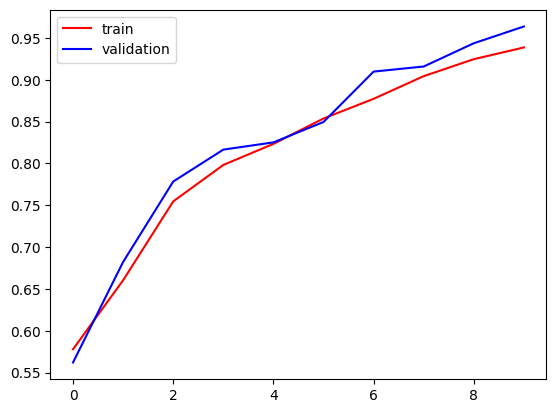

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"], color="red", label="train")
plt.plot(history.history["val_accuracy"], color="blue", label="validation")
plt.legend()
plt.show()

In [18]:
import warnings
warnings.filterwarnings('ignore')

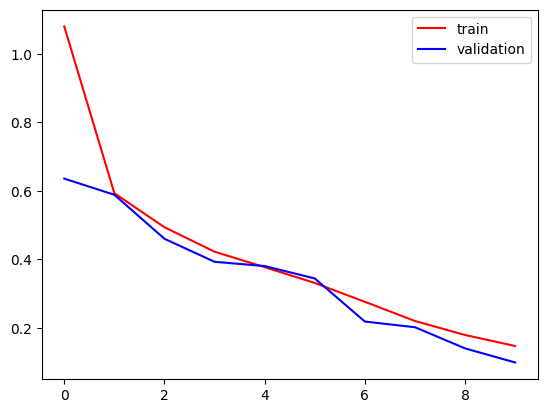

In [19]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [20]:
# Way to reduce Overfitting
# Add more data
# Data Augmentation
# L1/L2 Regularizer
# Dropout
# Batch Norm
# Reduce Complexity

In [60]:
# Testing for cat
import cv2
import numpy as np

class_names = ['Cat', 'Dog']  # adjust if your order is different

test_img = cv2.imread('/content/cat.jpg')

# BGR → RGB
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

test_img = cv2.resize(test_img, (224,224))

test_input = test_img.reshape((1,224,224,3))

# normalize
test_input = test_input.astype('float32') / 255.0

prediction = model.predict(test_input)

# 🔥 convert to label + confidence
prob = prediction[0][0]

if prob > 0.5:
    label = class_names[1]   # Dog
    confidence = prob
else:
    label = class_names[0]   # Cat
    confidence = 1 - prob

print("Predicted:", label)
print("Confidence:", round(confidence * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted: Cat
Confidence: 99.76 %


In [61]:
# Testing for dog
import cv2
import numpy as np

class_names = ['Cat', 'Dog']  # adjust if your order is different

test_img = cv2.imread('/content/dog.jpg')

# BGR → RGB
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

test_img = cv2.resize(test_img, (224,224))

test_input = test_img.reshape((1,224,224,3))

# normalize
test_input = test_input.astype('float32') / 255.0

prediction = model.predict(test_input)

# 🔥 convert to label + confidence
prob = prediction[0][0]

if prob > 0.5:
    label = class_names[1]   # Dog
    confidence = prob
else:
    label = class_names[0]   # Cat
    confidence = 1 - prob

print("Predicted:", label)
print("Confidence:", round(confidence * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted: Dog
Confidence: 73.11 %
